# How do we measure basic line diagnostics?

Here we discuss how to measure line diagnostics for individual emission lines. We'll work with an extracted HeNeAr emission line spectrum from the SBO 24" spectrograph, focusing first on an individual line. The demonstration below assumes your spectrum is still in units of wavelength pixel, rather than actual wavelength; as such, it forms a good basis for doing the initial fitting steps needed to determine a wavelength calibration from the pixel locations of known emission features. For other purposes, it should work just as well if you replace the pixel-based axis with a genuine wavelength one. 

In [1]:
# do some basic imports
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.table import QTable

# make matplotlib plots play nicely with astropy units
from astropy.visualization import quantity_support
quantity_support();

# make interactive plots 
%matplotlib ipympl

## Load a HeNeAr Wavelength Calibration Spectrum

Let's load an example 1D spectrum from the SBO spectrograph into a data table, which we extracted back when talking about [photons](photons.ipynb). This spectrum was produced by averaging together a few rows from the center of a 2D spectrograph image. As we read it here, `astropy` units are attached to each column. 

In [2]:
uncalibrated = QTable.read('data/sbo/extracted-HeNeAr-pixels.ecsv', format='ascii.ecsv')
uncalibrated

wavelength_pixel,flux,uncertainty
pix,ph / (pix s),ph / (pix s)
float64,float64,float64
0.0,13.566,5.782850542768679
1.0,5.32,5.019498022711036
2.0,3.99,4.885218562152567
3.0,6.118,5.098368405676467
4.0,7.448,5.22717518359582
5.0,23.40800000000001,6.579009074321148
6.0,-1.596,4.275436866566971
7.0,10.374,5.499941854238098


This spectrum has the wavelength dimension still in units of pixels, representing the column along the detector. By the end of this notebook, we'll convert these pixels into actual wavelengths.

In [3]:
uncalibrated['wavelength_pixel']

<Quantity [0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 1.1653e+04, 1.1654e+04,
           1.1655e+04] pix>

The flux, and uncertainty, are expressed as a photon rate, in units of $\sf photons/s/pixel$. Because the HeNeAr do not emit much continuum between the strong emission lines, the spectrum is consistent with zero over many pixels, with uncertainties scattering it above and below.

In [4]:
uncalibrated['flux']

<Quantity [13.566,  5.32 ,  3.99 , ...,  0.266, 10.108,  7.182] ph / (pix s)>

This particular file also has a little bit of metadata added summarizing a few basic details of the observation, including the grating tilt and slit width for this particular exposure.

In [5]:
uncalibrated.meta

{'telescope': 'Sommers-Bausch Observatory Leto (24")',
 'grating-tilt': 'about -10 degrees',
 'slit-width': '20 microns',
 'focus': 'probably not great',
 'lamp(s)': 'HeNeAr'}

This spectrum is "uncalibrated" in the sense that the wavelength axis is still in units of pixels. Let's first plot the spectrum on a linear scale. 

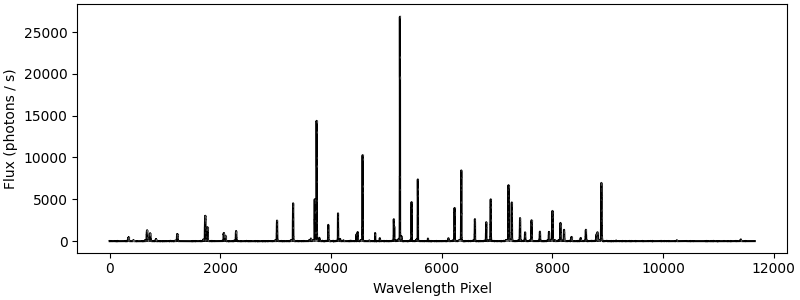

In [6]:
def plot_spectrum_from_table(table):
    ''' 
    A quick wrapper to plot an uncalibrated spectrum from a table. 
    '''

    # extract the arrays we need
    pixel = uncalibrated['wavelength_pixel']
    flux = uncalibrated['flux']
    uncertainty = uncalibrated['uncertainty']

    # plot the spectrum
    plt.step(pixel, flux, where='mid', color='black')
    plt.errorbar(pixel, flux, uncertainty, linewidth=0, elinewidth=1, color='gray', alpha=0.5)
    plt.xlabel('Wavelength Pixel')
    plt.ylabel('Flux (photons / s)')

plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum_from_table(uncalibrated);

Since there are some very bright lines and some much fainter ones, it might help to look at this on a log scale. Here the uncertainties will look a little funny in places where the flux is close enough to zero that the errorbar might stretch to negative values. However, we can see many more of the real spectral lines at once.

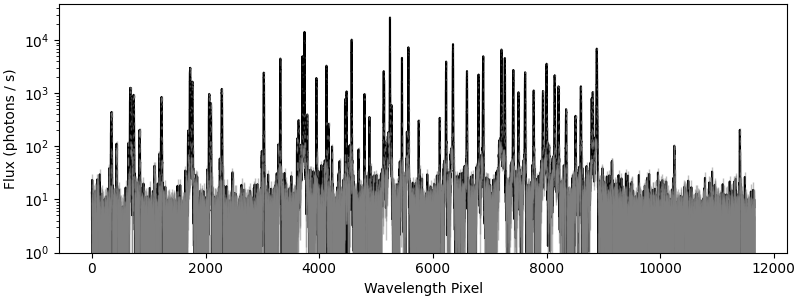

In [7]:
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum_from_table(uncalibrated)
plt.yscale('log')
plt.ylim(1, None);

## Focusing on One Line

Let's try to measure some basic line diagnostics for one line in this emission specturm. We'll use [`specutils`](https://specutils.readthedocs.io/en/stable/) to do this, which is full of tools for spectrum analysis and modeling. To do so, we'll need to start by converting our data table into a `specutils.Spectrum` object.

In [8]:
from specutils import Spectrum
from astropy.nddata import StdDevUncertainty

# create a specutils "Spectrum" object, including uncertainty that can be propagated
spectrum = Spectrum(spectral_axis=uncalibrated['wavelength_pixel'], 
                    flux=uncalibrated['flux'],
                    uncertainty=StdDevUncertainty(uncalibrated['uncertainty']))

spectrum

<Spectrum(flux=[13.566 ... 7.182] ph / (pix s) (shape=(11656,), mean=94.90942 ph / (pix s)); spectral_axis=<SpectralAxis [0.0000e+00 1.0000e+00 2.0000e+00 ... 1.1653e+04 1.1654e+04 1.1655e+04] pix> (length=11656); uncertainty=StdDevUncertainty)>

This spectrum object still has no wavelength calibration, so the `spectral_axis` is still in units of pixels. Let's write another little wrapper to be able to plot `Spectrum` objects like this.

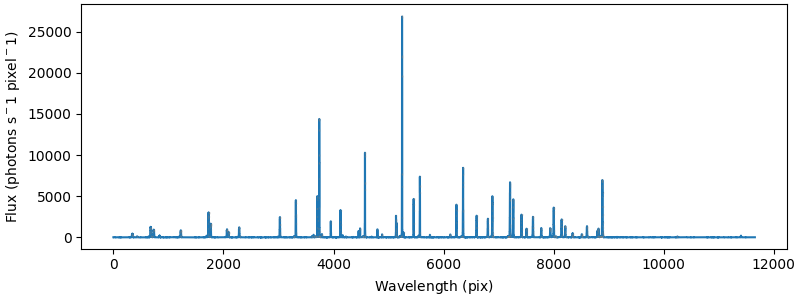

In [9]:
def plot_spectrum(spectrum, **kw):
    '''
    Make a plot of a specutils.Spectrum object.

    Parameters 
    ----------
    spectrum : specutils.Spectrum
        The main input should be a spectrum stored 
        as a `specutils` object, with `.spectral_axis`
        and `.flux` attributes attached.
    **kw : dict 
        All other keywords will be passed into the 
        `plt.step` plotting function. 
    '''

    # extract the arrays we need
    x = spectrum.spectral_axis
    flux = spectrum.flux
    uncertainty = spectrum.uncertainty.quantity

    # plot the spectrum
    plt.step(x, flux, where='mid', **kw)
    plt.errorbar(x, flux, uncertainty, linewidth=0, elinewidth=1, color='gray', alpha=0.5)

    # add some labels
    plt.xlabel(f'Wavelength ({x.unit.to_string(format="latex_inline")})')
    plt.ylabel('Flux (photons s$^-1$ pixel$^-1$)')

plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(spectrum)

Let's pick the line around wavelength pixel number $\sf w=8885~pixels$. We'll use `SpectralRegion` and `extract_region` to extract a small subregion, just centered on that line. By looking a subregion, we can fit just the line itself and the immediately surrounding pixels; we don't need to worry about other lines across the spectrum.

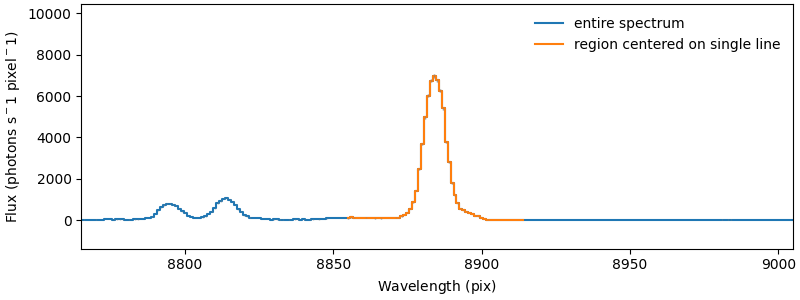

In [10]:
from specutils import SpectralRegion
from specutils.manipulation import extract_region

# define the pixels on which we want to focus
line_pixel = 8885*u.pixel
window = 30*u.pixel

# make a tiny sub-spsectrum from that region
sub_region = SpectralRegion(line_pixel - window, line_pixel + window)
sub_spectrum = extract_region(spectrum, sub_region)

# plot the region over the overall spectrum
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(spectrum, label='entire spectrum')
plot_spectrum(sub_spectrum, label='region centered on single line')
plt.legend(frameon=False)
plt.xlim(line_pixel - window*4, line_pixel + window*4)
plt.ylim(None, np.max(sub_spectrum.flux)*1.5);


Just like any `Spectrum` object, we can access the data in this "sub-spectrum" centered just on the line via the `.spectral_axis` and `.flux` attributes.

In [11]:
sub_spectrum.spectral_axis

<SpectralAxis [8855., 8856., 8857., 8858., 8859., 8860., 8861., 8862., 8863., 8864.,
   8865., 8866., 8867., 8868., 8869., 8870., 8871., 8872., 8873., 8874.,
   8875., 8876., 8877., 8878., 8879., 8880., 8881., 8882., 8883., 8884.,
   8885., 8886., 8887., 8888., 8889., 8890., 8891., 8892., 8893., 8894.,
   8895., 8896., 8897., 8898., 8899., 8900., 8901., 8902., 8903., 8904.,
   8905., 8906., 8907., 8908., 8909., 8910., 8911., 8912., 8913., 8914.] pix>

In [12]:
sub_spectrum.flux

<Quantity [ 8.964200e+01,  1.473640e+02,  1.292760e+02,  1.090600e+02,
            1.189020e+02,  1.103900e+02,  1.292760e+02,  1.234240e+02,
            1.021440e+02,  9.256800e+01,  1.165080e+02,  8.884400e+01,
            1.045380e+02,  9.921800e+01,  1.082620e+02,  1.157100e+02,
            1.322020e+02,  1.284780e+02,  1.888600e+02,  2.519020e+02,
            3.753260e+02,  5.695060e+02,  8.775340e+02,  1.435868e+03,
            2.491622e+03,  3.688090e+03,  4.986968e+03,  6.017452e+03,
            6.746558e+03,  6.959358e+03,  6.763050e+03,  6.268556e+03,
            5.422144e+03,  3.782786e+03,  2.810822e+03,  1.805342e+03,
            1.204980e+03,  8.349740e+02,  5.636540e+02,  4.788000e+02,
            4.184180e+02,  3.521840e+02,  3.093580e+02,  2.292920e+02,
            1.846040e+02,  1.048040e+02,  6.171200e+01,  3.670800e+01,
            2.713200e+01,  2.287600e+01,  1.649200e+01,  2.739800e+01,
            1.622600e+01,  2.473800e+01,  1.542800e+01,  1.064000e+01,
      

## Line Diagnostics from `specutils.analysis`

Let's start using the tools in `specutils.analysis` to measure a few key line diagnostics. Here, we will try to measure...

- the line centroid
- the line integrated flux
- various metics of the line width

Let's calculate the *line centroid*, the center of the line. You'll notice the centroid calculated below is in fracitonal pixels; that's because the flux-weighted centroid algorithm is averaging together information from multiple pixels, getting position precision that can be finer even than an individual pixel.

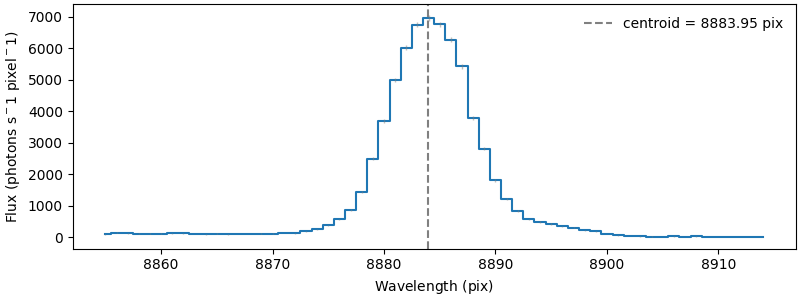

In [13]:
from specutils.analysis import centroid

# calculate the flux-weight centroid of the region sub-spectrum
this_line_centroid = centroid(sub_spectrum)

# plot the centroid
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)
plt.axvline(this_line_centroid, color='gray', linestyle='--', label=f'centroid = {this_line_centroid:.2f}')
plt.legend(frameon=False);

Let's calculate the *line flux*, the total flux in the line, integrated over all pixels. If the flux is in units of $\sf photons/s/pixel$ and the spectral axis is in units of $\sf pixels$, then the integrated flux will be in units of $\sf photons/s$. In this example, if we back-of-the-envelope estimate a height of $\sf 700~photons/s/pixel$ and a width of $\sf 10~pixels$, it should make sense that the integral works out to about $\sf 7000~photons/s$.

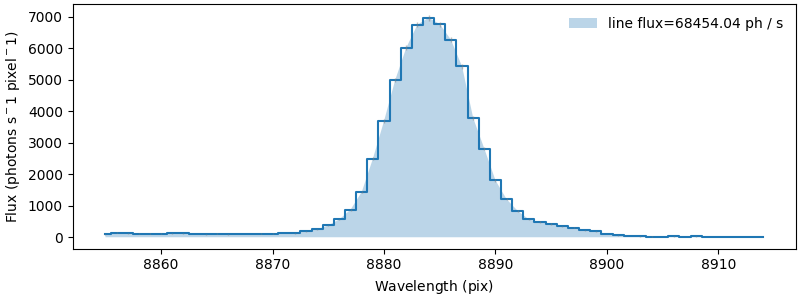

In [14]:
from specutils.analysis import line_flux

# calculate the line flux
this_line_flux = line_flux(sub_spectrum)

# plot the line flux
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)

# draw the area being integrated
plt.fill_between(sub_spectrum.spectral_axis, sub_spectrum.flux, alpha=0.3, label=f'line flux={this_line_flux:.2f}')
plt.legend(frameon=False);

Finally, let's calculate a few estimates of the line width. There are a couple methods we might use:
- `fwhm` = the full-width at half-maximum ($\sf FWHM$), calculated numerically, regardless of the shape of the line
- `fwzi` = the full-width at zero-intensity, where the line first drops to zero (with noise, this can be a bit less stable than the $\sf FWHM$)

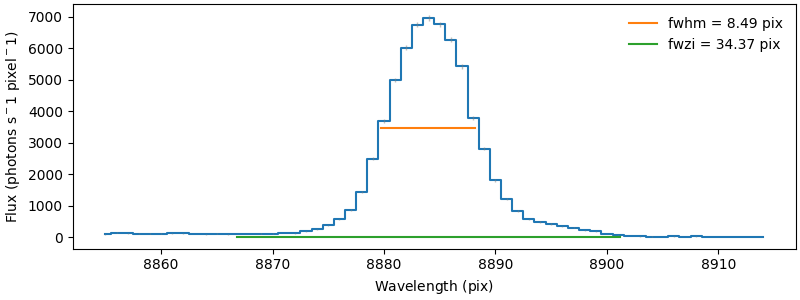

In [15]:
from specutils.analysis import fwhm, fwzi

# calculate various types of line width
this_line_fwhm = fwhm(sub_spectrum)
this_line_fwzi = fwzi(sub_spectrum)

plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)

# draw a line for the FWHM
x = this_line_centroid + [-0.5,0.5]*this_line_fwhm
y = 0.5*np.max(sub_spectrum.flux)*np.ones(2)
plt.plot(x, y, label=f"fwhm = {this_line_fwhm:.2f}")

# draw a line for the FWZI
x = this_line_centroid + [-0.5,0.5]*this_line_fwzi
y = np.zeros(2)
plt.plot(x, y, label=f"fwzi = {this_line_fwzi:.2f}")

plt.legend(frameon=False);

Let's put these all together into one plot:

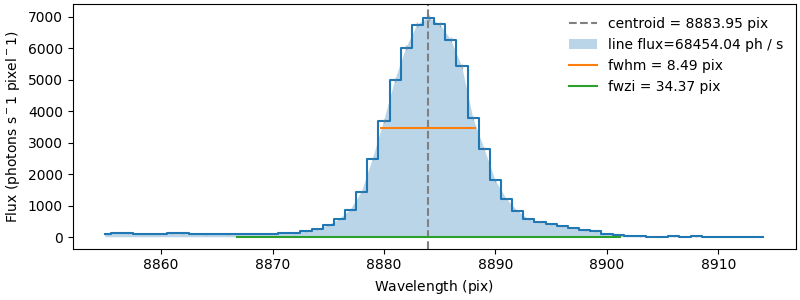

In [16]:
from specutils.analysis import centroid

# calculate the flux-weight centroid of the region sub-spectrum
this_line_centroid = centroid(sub_spectrum)

# calculate the line flux
this_line_flux = line_flux(sub_spectrum)

# calculate various types of line width
this_line_fwhm = fwhm(sub_spectrum)
this_line_fwzi = fwzi(sub_spectrum)

# plot the centroid
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)
plt.axvline(this_line_centroid, color='gray', linestyle='--', label=f'centroid = {this_line_centroid:.2f}')

# draw the area being integrated
plt.fill_between(sub_spectrum.spectral_axis, sub_spectrum.flux, alpha=0.3, label=f'line flux={this_line_flux:.2f}')

# draw a line for the FWHM
x = this_line_centroid + [-0.5,0.5]*this_line_fwhm
y = 0.5*np.max(sub_spectrum.flux)*np.ones(2)
plt.plot(x, y, label=f"fwhm = {this_line_fwhm:.2f}")

# draw a line for the FWZI
x = this_line_centroid + [-0.5,0.5]*this_line_fwzi
y = np.zeros(2)
plt.plot(x, y, label=f"fwzi = {this_line_fwzi:.2f}")

plt.legend(frameon=False);

## Line Modeling with `specutils.fitting`

The above [`specutils.analysis`](https://specutils.readthedocs.io/en/stable/analysis.html) tools can be a very quick and handy way to estimate the basic properties of a line. If you want to do more nuanced modeling of line shapes, you might want to dive into [`specutils.fitting`](https://specutils.readthedocs.io/en/stable/fitting.html#line-spectrum-fitting). We'll show a very brief version of that here, but refer you to the documentation for oodles more details and options. 

Here, we set an initial guess for a modeled Gaussian, and then we optimize the parameters (the `mean`, the `amplitude`, the `stddev`) of that model. In general, this approach can be fairly sensitive to the initial conditions -- if you set your guess a little too far away or a little too wide, it might not converge to the right answer! 

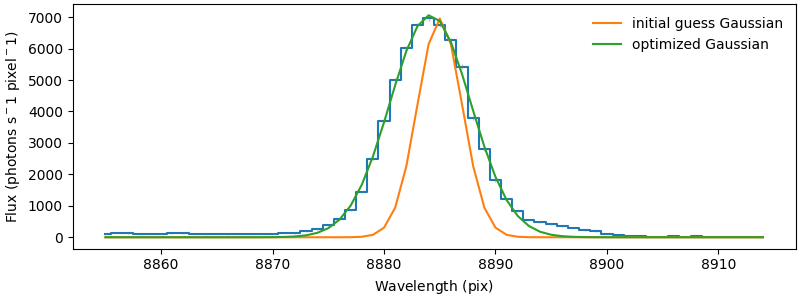

In [17]:
from specutils.fitting import estimate_line_parameters, fit_lines
from astropy.modeling import models

# define an initial guess for the Gaussian line model
gaussian_initial_guess = models.Gaussian1D(mean=line_pixel, stddev=2*u.pix, amplitude=np.max(sub_spectrum.flux))

# optimize the parameters of that initial guess
gaussian_optimized = fit_lines(sub_spectrum, gaussian_initial_guess)

# plot the spectrum
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)

# plot the initial guess model
plt.plot(sub_spectrum.spectral_axis, gaussian_initial_guess(sub_spectrum.spectral_axis), label=f'initial guess Gaussian')

# plot the optimized model 
plt.plot(sub_spectrum.spectral_axis, gaussian_optimized(sub_spectrum.spectral_axis), label=f'optimized Gaussian')
plt.legend(frameon=False);


Let's try to put this Gaussian fit all together, in a way that we can compare with the `specutils.analysis` approach way above. To directly compare, we'll rely on a neat mathematical result that the FWHM of a Gaussian with width $\sf \sigma$ is $\sf FWHM = 2\sqrt{2\ln 2} \sigma$, to express the fitted standard deviation of the Gaussian on comparable footing to the FWHM above.

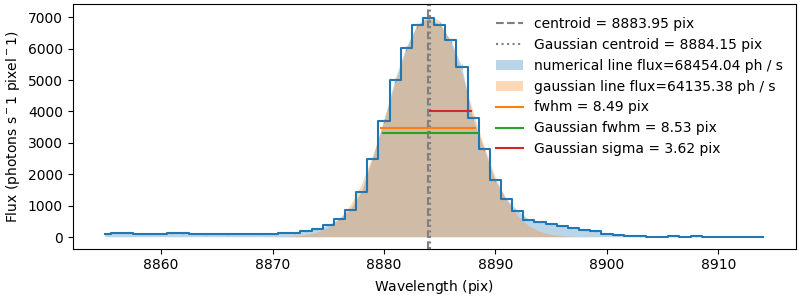

In [18]:
# plot the spectrum
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)

# extract the optimized model parameters
gaussian_line_centroid = gaussian_optimized.mean.quantity
gaussian_line_sigma = gaussian_optimized.stddev.quantity
gaussian_line_amplitude = gaussian_optimized.amplitude.quantity

# calculate integrated line flux from the integral of a Gaussian
gaussian_line_flux = gaussian_line_amplitude*np.sqrt(2*np.pi*gaussian_line_sigma**2)
gaussian_line_fwhm = gaussian_optimized.fwhm

# plot the centroid
plt.axvline(this_line_centroid, color='gray', linestyle='--', label=f'centroid = {this_line_centroid:.2f}')
plt.axvline(gaussian_line_centroid, color='gray', linestyle=':', label=f'Gaussian centroid = {gaussian_line_centroid:.2f}')

# draw the area being integrated
plt.fill_between(sub_spectrum.spectral_axis, sub_spectrum.flux, alpha=0.3, label=f'numerical line flux={this_line_flux:.2f}')
plt.fill_between(sub_spectrum.spectral_axis, gaussian_optimized(sub_spectrum.spectral_axis), alpha=0.3, label=f'gaussian line flux={gaussian_line_flux:.2f}')

# draw a line for the FWHM
x = this_line_centroid + [-0.5,0.5]*this_line_fwhm
y = 0.5*np.max(sub_spectrum.flux)*np.ones(2)
plt.plot(x, y, label=f"fwhm = {this_line_fwhm:.2f}")
x = gaussian_line_centroid + [-0.5,0.5]*gaussian_line_fwhm
plt.plot(x, y*.95, label=f"Gaussian fwhm = {gaussian_line_fwhm:.2f}")

# draw a line for the FWHM
x = gaussian_line_centroid + [0,1]*gaussian_line_sigma
y = np.exp(-0.5)*np.max(sub_spectrum.flux)*np.ones(2)
plt.plot(x, y*.95, label=f"Gaussian sigma = {gaussian_line_sigma:.2f}")

plt.legend(frameon=False);

*Please note that the approaches shown here rely on the spectrum either not having a continuum.* If your spectrum does have some significant continuum, consider subtracting it using some kind of [continuum fit](https://specutils.readthedocs.io/en/stable/fitting.html#continuum-fitting).

Now we have two handy methods for estimating line diagnostics for emission lines. These may come in handy when trying to do some [wavelength calibration](wavelength.ipynb)!